In [1]:
import sys

sys.path.append('src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

from redun import redun_py
from utils import hoeffding_d

plt.style.use('ggplot')

# Data Reduction

In a dataset, not all the predictors are informative. If we don't use a proper regularized model, we need to reduce these variables by either selecting or combining them before model fitting, since we have limited degrees of freedom to spend.

To apply any data reduction method well, we first need to understand the term *bias*. We already mentioned it in the previous notebooks but we haven't gone deep into the subject yet. So let's start with its formal definition and see how it relates to data reduction.


## Bias

All data reduction methods introduce a bias risk to the model at different levels. Bias of an estimator $\hat{\theta}$ is formulated as:

$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$

where $\theta$ is the true (unknown) parameter value and $\hat{\theta}$ is the estimator we compute from the data. Whenever we manipulate the dataset or the model, we risk changing the sampling distribution of $\hat{\theta}$, and thus $E[\hat{\theta}]$. For example, if we tweak the model such that it performs better on the data we have, we may move $E[\hat{\theta}]$ further away from the real $\theta$ value.

Our goal is not to create bias-free models, but rather models with minimum bias. There are two kinds of bias we should keep apart.

**Selection bias** (selecting and transforming $X$ based on $Y$) is the bias we need to avoid as much as possible, because doing this obviously overfits the model and produces artificially small standard errors and overly optimistic p-values.

**Omitted variable bias** is the other one. We cannot completely avoid this: if $x_i$ is related to $x_j$ but is omitted from the model while still having a genuine impact on $Y$, then the coefficient estimate of $x_j$ becomes biased (it partly absorbs the effect that should belong to $x_i$). This is a bias in the point estimate itself, not just in its standard error or p-value. We cannot identify such confounding without fitting more than one model to the data, which is not good practice since it increases the Type I error probability.

In general, we specifically avoid selection bias and accept the risk of omitted variable bias, since the benefits of data reduction outweigh that risk.


## Collinearity

Collinearity is the term we use whenever a predictor can be largely explained by a linear combination of the other predictors. If collinearity is present, the statistical power of the tests regarding predictor coefficients decreases. Also using the parameter coefficients for inference purposes is misleading.

## Variance Inflation Factor (VIF)

Variance Inflation Factor is a method for detecting collinearities. The algorithm measures how much the variance of a predictor's estimated coefficient is inflated by its correlation with the other predictors. Since it only uses $X$ and never looks at $Y$, the bias risk it introduces is relatively low.

$VIF_i = \frac{1}{1 - R^2_{x_i}}$

Where $R^2_{x_i}$ is the $R^2$ value from a regression of $x_i$ on all the other predictors:

$\hat{x_i} = b_0 + b_1 x_1 + \dots + b_{i-1} x_{i-1} + b_{i+1} x_{i+1} + \dots + b_p x_p$

The higher this $R^2$, the more $x_i$ overlaps with the rest, and the larger its VIF becomes. Let's see it on a dataset.

**Example**

$n = 100$

$x_1 \sim \mathcal{N}(50,\ 10^2)$

$x_2 = x_1 + \varepsilon$

$x_3 \sim \mathcal{N}(30,\ 5^2)$

$\varepsilon \sim \mathcal{N}(0,\ 5^2)$

We build $x_2$ on top of $x_1$, so we expect these two to be collinear and get high VIF values. On the other hand, $x_3$ is independent, so its VIF should stay close to 1.


In [2]:
np.random.seed(1)
x1 = np.random.normal(50, 10, 100)
x2 = x1 + np.random.normal(0, 5, 100) 
x3 = np.random.normal(30, 5, 100)

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3
})

X = sm.add_constant(df)
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

  feature        VIF
0   const  74.701754
1      x1   5.194730
2      x2   5.205396
3      x3   1.043826


The VIF value of the constant is not taken into consideration. Still what should we understand from the VIF value of the predictors? Here is a table which can be used to interpret the results:

| VIF Range | Interpretation |
|-----------|----------------|
| 1         | No correlation with the other predictors |
| 1-5       | Moderate correlation, generally acceptable |
| 5-10      | High correlation, warrants further investigation |
| >10       | Severe multicollinearity, action needed |

## Redundancy Analysis

VIF tells us when a single predictor is explained by the others, but it only looks at linear relationships one variable at a time. In his book, Frank Harrell introduces a more complex algorithm that is able to consider nonlinear relationships as well. I added an equivalent .py code in the source section.

The `redun` algorithm works like the following:

- Determine a threshold $R^2$ for data elimination. The higher we set it, the more conservative the algorithm becomes. In other words, a variable is dropped only when the others explain it almost perfectly, so fewer variables get removed.

For each variable:

- Fit an RCS to the rest of the variables. Represent continuous variables as splines and categorical ones with one hot encoding.

- Look at $R^2$ score of the model fit. If it passes the threshold $R^2$ that we determined at the first step, the algorithm drops that feature from the dataset.

The algorithm repeats the steps above until no remaining variable can be predicted above the threshold.

To see the original explanation please refer to Regression Modeling Strategies - Section 4.7.1. 

Since the whole procedure uses $X$ and never touches $Y$, it is free from selection bias. Let's see it on an example.

**Example**

$n = 300$

$\text{weight} \sim \mathcal{N}(70,\ 12^2)$

$\text{height} \sim \mathcal{N}(170,\ 10^2)$

$\text{age} \sim U(20,\ 80)$

$\text{income} \sim \mathcal{N}(50,\ 15^2)$

Two of the predictors are built from the others:

$\text{bmi} = \dfrac{\text{weight}}{(\text{height}/100)^2} + \varepsilon_1$

$\text{waist} = 0.5\,\text{weight} + \varepsilon_2$

$\varepsilon_1 \sim \mathcal{N}(0,\ 0.1^2)$

$\varepsilon_2 \sim \mathcal{N}(0,\ 2^2)$

Since `bmi` and `waist` are both built from `weight`, `weight` can be reconstructed from them. On the other hand, `age` and `income` are independent, so we expect them to stay.


In [3]:
np.random.seed(0)
n = 300
weight = np.random.normal(70, 12, n)
height = np.random.normal(170, 10, n)
bmi = weight / (height / 100) ** 2 + np.random.normal(0, 0.1, n)
waist = 0.5 * weight + np.random.normal(0, 2, n)
age = np.random.uniform(20, 80, n)
income = np.random.normal(50, 15, n)

data = pd.DataFrame({
    "age": age,
    "weight": weight,
    "height": height,
    "bmi": bmi,
    "waist": waist,
    "income": income,
})

result = redun_py(data, r2_threshold=0.9)
print("\nKept   :", result["In"])
print("Dropped:", result["Out"])


Redundancy Analysis
n: 300   p: 6   nk: 4
Number of incomplete rows: 0
R2 cutoff: 0.9   Type: adjusted

R2 with which each variable can be predicted from all others:
              age: -0.005   (n=300)
           weight: 0.945   (n=300)
           height: 0.711   (n=300)
              bmi: 0.710   (n=300)
            waist: 0.886   (n=300)
           income: 0.013   (n=300)

Removing          weight  (R2=0.9450)

Kept   : ['age', 'height', 'bmi', 'waist', 'income']
Dropped: ['weight']


The algorithm dropped `weight` and kept the rest. This makes sense. We built `bmi` and `waist` directly from `weight`, so once we have them (together with `height`), `weight` no longer carries new information. Its $R^2$ of 0.945 confirms that the other predictors reconstruct it almost perfectly.


## Variable Clustering

Variable Clustering is the last data reduction method in this series. To reduce the number of predictors, it merges them instead of dropping any. Some loss of information and interpretability is accepted in return for reduced model complexity.


### Clustering Metric

To determine which variables to combine we can look at different metrics. Pearson correlation is the most common one. It works great to detect linear relationships but since linearity is not a necessity, using Pearson only might not be enough. We can use Spearman correlation which looks at the monotonic change between variables. But this metric might not be enough in more complex patterns such as a U shaped one. Alternatively, we can look at the Hoeffding D, which measures how much the joint distribution of two variables deviates from the product of their marginals. Since it compares the full joint behaviour rather than just a linear or monotonic trend, it can even catch non-monotonic relationships like a U shape. However, this metric might penalize the noise too much, resulting in a lower score.

Let's see how these metrics behave in different correlation scenarios:

**Example**

We generate one predictor and build three different responses on top of it, each with the same small amount of noise.

$n = 300$

$x_1 \sim U(-3,\ 3)$

$\varepsilon \sim \mathcal{N}(0,\ 0.1^2)$

Linear Dataset:

$x_2 = x_1 + \varepsilon$

Monotonic Dataset:

$x_2 = e^{x_1} + \varepsilon$

U Shaped Dataset:

$x_2 = x_1^2 + \varepsilon$


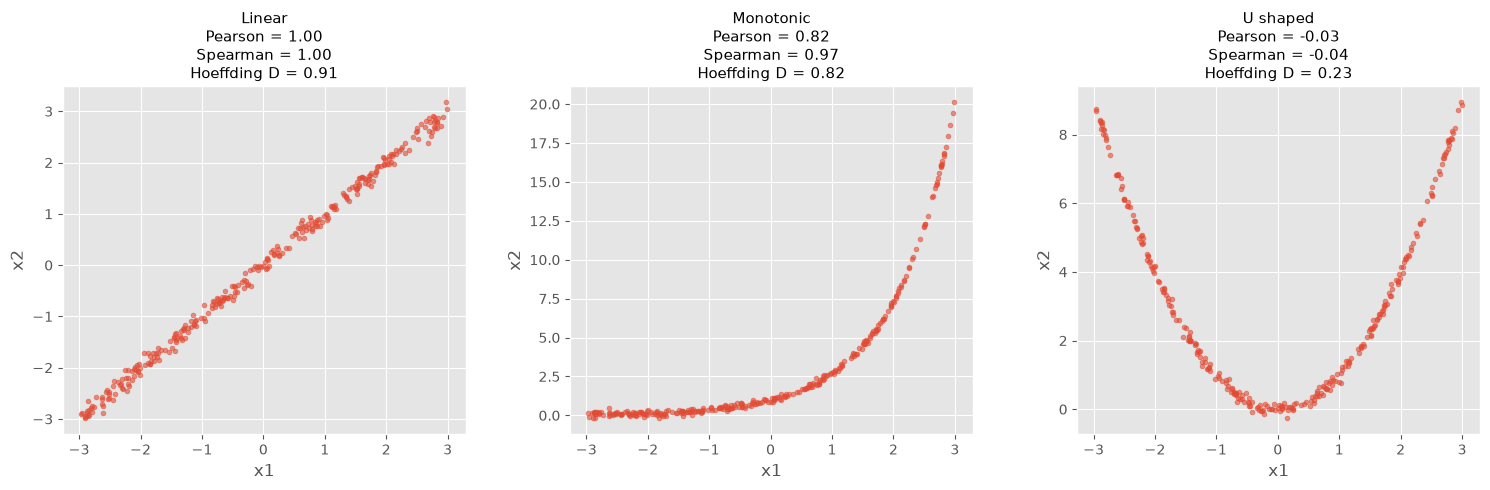

In [4]:
rng = np.random.default_rng(1)
n = 300
x1 = rng.uniform(-3, 3, n)


linear = x1 + rng.normal(0, 0.1, n)
monotonic = np.exp(x1) + rng.normal(0, 0.1, n)
u_shaped = x1 ** 2 + rng.normal(0, 0.1, n)

datasets = {
    "Linear": linear,
    "Monotonic": monotonic,
    "U shaped": u_shaped,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, x2) in zip(axes, datasets.items()):
    p = pearsonr(x1, x2)[0]
    s = spearmanr(x1, x2)[0]
    h = hoeffding_d(x1, x2)
    ax.scatter(x1, x2, s=12, alpha=0.6)
    ax.set_title(
        f"{title}\n"
        f"Pearson = {p:.2f}\n"
        f"Spearman = {s:.2f}\n"
        f"Hoeffding D = {h:.2f}",
        fontsize=11,
    )
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout(w_pad=3)
plt.show()


Hoeffding D behaves more conservatively on the linear and monotonic datasets due to its noise sensitivity. On the other hand, it is the only metric that manages to catch the relationship in the U shaped dataset.


### Agglomerative Clustering

Once we pick a metric, clustering works in a few steps. First we compute the chosen similarity between every pair of variables and collect them into a similarity matrix. Then we turn similarity into distance, because two variables that are highly related should sit close to each other. A common choice is to subtract the similarity from one, so that more similar variables get a smaller distance:

$d = 1 - \text{similarity}$

We feed this distance matrix into a hierarchical (agglomerative) clustering algorithm. Using this matrix, the algorithm starts merging variables from the closest to the furthest, until all of them are linked together. The resulting tree-like structure is called a dendrogram. We use the dendrogram to decide which variables to group within each cluster. Technically we could do this by reading the similarity matrix directly, but grouping is much easier on a dendrogram. It also has a communication benefit. A dendrogram makes it far easier to explain what we did than a big similarity matrix.

Let's see an example.


**Example**

We build a dataset with two hidden factors and one independent variable. The first factor drives the body measurements, the second drives the financial figures, and `age` stands on its own.

$n = 300$

$f_1 \sim \mathcal{N}(0,\ 1)$

$f_2 \sim \mathcal{N}(0,\ 1)$

$\text{height} = 170 + 10\,f_1 + \varepsilon_{\text{height}}$

$\text{weight} = 70 + 12\,f_1 + \varepsilon_{\text{weight}}$

$\text{waist} = 80 + 8\,f_1 + \varepsilon_{\text{waist}}$

$\text{income} = 50 + 15\,f_2 + \varepsilon_{\text{income}}$

$\text{savings} = 100 + 40\,f_2 + \varepsilon_{\text{savings}}$

$\text{age} \sim U(20,\ 80)$

We will use Spearman correlation to compute the similarity matrix.

Since `height`, `weight` and `waist` share the same factor, we expect them to fall into one cluster. `income` and `savings` share the other factor, so they should form a second cluster. `age` is independent, so it should stay on its own.


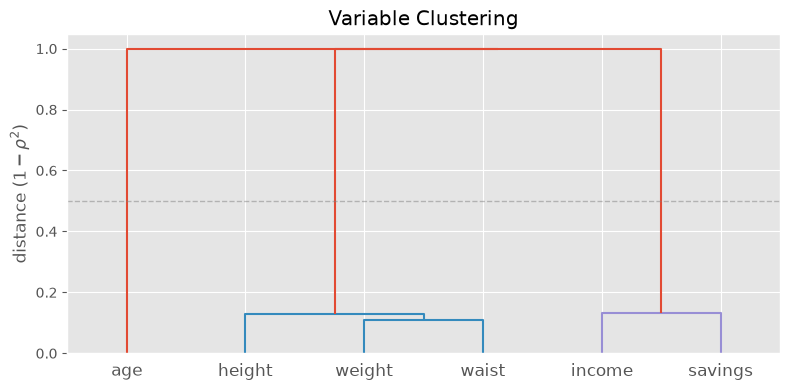

In [5]:
rng = np.random.default_rng(0)
n = 300

f1 = rng.normal(0, 1, n)
f2 = rng.normal(0, 1, n)

height = 170 + 10 * f1 + rng.normal(0, 3, n)
weight = 70 + 12 * f1 + rng.normal(0, 3, n)
waist = 80 + 8 * f1 + rng.normal(0, 2, n)

income = 50 + 15 * f2 + rng.normal(0, 3, n)
savings = 100 + 40 * f2 + rng.normal(0, 10, n)

age = rng.uniform(20, 80, n)

data = pd.DataFrame({
    "height": height,
    "weight": weight,
    "waist": waist,
    "income": income,
    "savings": savings,
    "age": age,
})

rho, _ = spearmanr(data)
sim = rho ** 2


dist = 1 - sim
np.fill_diagonal(dist, 0.0)
Z = linkage(squareform(dist, checks=False), method="average")

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=data.columns.tolist())
plt.axhline(y = 0.5, linestyle='--', color='gray', linewidth=1, alpha=0.5)
plt.ylabel(r"distance ($1 - \rho^2$)")
plt.title("Variable Clustering")
plt.tight_layout()
plt.show()


The dendrogram matches what we expected. `height`, `weight` and `waist` merge early into one cluster because they share $f_1$, `income` and `savings` into another because they share $f_2$, and `age` only joins at the very top, so it stays on its own. We cut the tree at a height of $0.5$, which cleanly separates these three groups.


### Reducing Clusters to First Principal Components

Now we turn each cluster into a single score. We standardize the members first:

$x_{i,\text{scaled}} \leftarrow \dfrac{x_i - \bar{x}_i}{\sigma_i} \quad \text{for } i = 1, 2, \dots, p$

so that variables on different scales contribute equally.(*)

Then we take the first principal component of each cluster.

(*) We will cover this topic in detail in the Data Transformations notebook.


In [6]:
labels = fcluster(Z, t=0.5, criterion="distance")

clusters = {}
for col, lab in zip(data.columns, labels):
    clusters.setdefault(lab, []).append(col)

reduced = {}
for members in clusters.values():
    block = data[members]
    scaled = StandardScaler().fit_transform(block)
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(scaled)[:, 0]
    name = " + ".join(members)
    reduced[name] = pc1
    evr = 100 * pca.explained_variance_ratio_[0]
    print(f"cluster score '{name}' <- {members} - Explained Variance Ratio (%): {evr:.2f}")

reduced = pd.DataFrame(reduced)
reduced.head()


cluster score 'height + weight + waist' <- ['height', 'weight', 'waist'] - Explained Variance Ratio (%): 95.93
cluster score 'income + savings' <- ['income', 'savings'] - Explained Variance Ratio (%): 97.20
cluster score 'age' <- ['age'] - Explained Variance Ratio (%): 100.00


,height + weight + waist,income + savings,age
0,-0.194842,1.973629,0.333999
1,-0.148031,0.691553,0.691763
2,1.333304,0.922242,1.684451
3,0.313161,-5.625987,0.183589
4,-0.794169,0.194156,-0.223074


From the explained variance ratios, we can conclude that first principal components represent each cluster well. This means that we reduced six predictors into three scores with very little information loss.